# Amazon Prime Movies and TV Shows – Exploratory Data Analysis

---

## 1. Project Title
**Amazon Prime Movies and TV Shows – Exploratory Data Analysis (EDA)**

## 2. Project Objective
> *The objective of this project is to analyze Amazon Prime movies and TV shows and identify patterns in content type, release years, genres, ratings, runtimes, production countries, and cast information using Exploratory Data Analysis techniques.*

## 3. Technologies Used
* **Python**: Core programming language for data analysis and scripting.
* **Pandas**: High-performance data manipulation, cleaning, aggregation, and restructuring.
* **NumPy**: Numerical operations and mathematical computations.
* **Matplotlib**: Core plotting engine for customizable static visualizations.
* **Seaborn**: Statistical data visualization library built on Matplotlib for aesthetic styling and distributions.
* **Jupyter Notebook**: Interactive computing environment for documenting code, visualizations, and business insights side-by-side.

### Project Overview
Amazon Prime Video is one of the world's leading streaming entertainment platforms. This project explores its catalog of movies and television shows through systematic data cleaning, transformation, and exploratory analysis. Through structured visualizations, we answer key operational questions regarding content variety, historical growth, global production reach, critical reception, and prolific creative talent (actors and directors).

---
## 4. Import Libraries and Configuration
In this step, we import the necessary scientific and visualization libraries. We also configure display options and plotting aesthetics for a professional presentation.

In [1]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities for parsing stringified literals and filesystem paths
import ast
import os

# Set aesthetic style for all Seaborn plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Pandas display configuration for better tabular readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Ensure visualizations output directory exists
os.makedirs("../visualizations", exist_ok=True)
print("Libraries imported and configuration completed successfully.")

Libraries imported and configuration completed successfully.


---
## 5. Load the Datasets
We load the two datasets using relative paths:
1. `titles.csv`: Contains metadata about movies and TV shows (title, release year, runtime, genres, countries, IMDb/TMDB ratings).
2. `credits.csv`: Contains information about the cast and crew (person ID, title ID, actor/director names, character roles).

In [2]:
# Load the raw datasets using relative file paths
titles = pd.read_csv("../datasets/titles.csv")
credits = pd.read_csv("../datasets/credits.csv")

print("Titles Dataset Shape :", titles.shape)
print("Credits Dataset Shape:", credits.shape)

Titles Dataset Shape : (9871, 15)
Credits Dataset Shape: (124235, 5)


### 5.1 Preview the Raw Data
Let us inspect the first five rows of both datasets to understand their structure and attributes.

In [3]:
# Display first 5 rows of titles
print("--- Titles Dataset Head ---")
display(titles.head())

--- Titles Dataset Head ---


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [4]:
# Display first 5 rows of credits
print("--- Credits Dataset Head ---")
display(credits.head())

--- Credits Dataset Head ---


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### 5.2 Schema, Data Types, and Summary Statistics
Here we examine the schema information, non-null counts, column data types, and initial descriptive statistics.

In [5]:
# Inspect column types and non-null values for titles
print("=== TITLES INFO ===")
titles.info()

print("\n=== TITLES STATISTICAL SUMMARY ===")
display(titles.describe())

=== TITLES INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   str    
 1   title                 9871 non-null   str    
 2   type                  9871 non-null   str    
 3   description           9752 non-null   str    
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   str    
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   str    
 8   production_countries  9871 non-null   str    
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   str    
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [6]:
# Inspect column types and non-null values for credits
print("=== CREDITS INFO ===")
credits.info()

=== CREDITS INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   person_id  124235 non-null  int64
 1   id         124235 non-null  str  
 2   name       124235 non-null  str  
 3   character  107948 non-null  str  
 4   role       124235 non-null  str  
dtypes: int64(1), str(4)
memory usage: 9.1 MB


---
## 6. Data Cleaning and Preprocessing
Data cleaning ensures our dataset is robust, accurate, and ready for statistical analysis.

### Cleaning Tasks Performed:
1. **Duplicate Detection & Removal**: Identify and remove duplicate records while keeping the first occurrence.
2. **Missing Value Audit**: Check missing value counts and evaluate their structural meaning (e.g., `seasons` is naturally absent for movies).
3. **Working DataFrames**: Create isolated working copies (`titles_df` and `credits_df`) so original raw data is never mutated or overwritten.
4. **Data Type Standardization**: Safely convert numeric attributes (`release_year`, `runtime`, `seasons`, `imdb_score`, `imdb_votes`, `tmdb_popularity`, `tmdb_score`) to appropriate numeric types.
5. **Stringified List Parsing**: Attributes such as `genres` and `production_countries` are stored as string representations of Python lists (e.g., `"['drama', 'comedy']"`). We safely parse these into real Python lists using `ast.literal_eval` with error handling.

In [7]:
# 1. Create working copies to preserve original datasets
titles_df = titles.copy()
credits_df = credits.copy()

# 2. Check and remove duplicate rows
titles_dup_before = titles_df.duplicated().sum()
credits_dup_before = credits_df.duplicated().sum()

titles_df.drop_duplicates(inplace=True)
credits_df.drop_duplicates(inplace=True)

print(f"Titles duplicates removed: {titles_dup_before} (Remaining: {len(titles_df)})")
print(f"Credits duplicates removed: {credits_dup_before} (Remaining: {len(credits_df)})")

Titles duplicates removed: 3 (Remaining: 9868)
Credits duplicates removed: 56 (Remaining: 124179)


In [8]:
# 3. Missing values analysis
print("=== MISSING VALUES IN TITLES ===")
missing_titles = titles_df.isnull().sum()
missing_titles_pct = (missing_titles / len(titles_df)) * 100
missing_titles_summary = pd.DataFrame({
    'Missing Count': missing_titles,
    'Percentage (%)': missing_titles_pct.round(2)
})
display(missing_titles_summary[missing_titles_summary['Missing Count'] > 0])

print("\n=== MISSING VALUES IN CREDITS ===")
missing_credits = credits_df.isnull().sum()
missing_credits_summary = pd.DataFrame({
    'Missing Count': missing_credits,
    'Percentage (%)': ((missing_credits / len(credits_df)) * 100).round(2)
})
display(missing_credits_summary[missing_credits_summary['Missing Count'] > 0])

=== MISSING VALUES IN TITLES ===


,Missing Count,Percentage (%)
description,119,1.21
age_certification,6484,65.71
seasons,8511,86.25
imdb_id,667,6.76
imdb_score,1021,10.35
imdb_votes,1031,10.45
tmdb_popularity,547,5.54
tmdb_score,2080,21.08



=== MISSING VALUES IN CREDITS ===


,Missing Count,Percentage (%)
character,16277,13.11


In [9]:
# 4. Safe numeric conversion
numeric_cols = ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

for col in numeric_cols:
    if col in titles_df.columns:
        titles_df[col] = pd.to_numeric(titles_df[col], errors='coerce')

# 5. Safe parsing of list-like string columns (genres and production_countries)
def parse_list_safely(val):
    """Safely parse stringified list into a genuine Python list."""
    if pd.isna(val):
        return []
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        val = val.strip()
        if val.startswith('[') and val.endswith(']'):
            try:
                parsed = ast.literal_eval(val)
                return parsed if isinstance(parsed, list) else []
            except (ValueError, SyntaxError):
                return []
    return []

titles_df['genres_list'] = titles_df['genres'].apply(parse_list_safely)
titles_df['countries_list'] = titles_df['production_countries'].apply(parse_list_safely)

print("Data types after conversion:")
print(titles_df[['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']].dtypes)
print("\nSample parsed genres:", titles_df['genres_list'].head(3).tolist())
print("Sample parsed countries:", titles_df['countries_list'].head(3).tolist())

Data types after conversion:
release_year         int64
runtime              int64
seasons            float64
imdb_score         float64
imdb_votes         float64
tmdb_popularity    float64
tmdb_score         float64
dtype: object

Sample parsed genres: [['comedy', 'family', 'animation', 'action', 'fantasy', 'horror'], ['action', 'drama', 'war', 'western', 'comedy', 'european'], ['romance', 'war', 'drama']]
Sample parsed countries: [['US'], ['US'], ['US']]


---
## 7. Exploratory Data Analysis (EDA)

### Analysis 1: Movies vs. TV Shows Distribution
**Purpose:** Understand the distribution of catalog offerings between standalone feature films (`MOVIE`) and episodic series (`SHOW`).

,Count,Percentage (%)
type,,
MOVIE,8511,86.25
SHOW,1357,13.75


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\4093964515.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[0], palette=['#1f77b4', '#ff7f0e'])


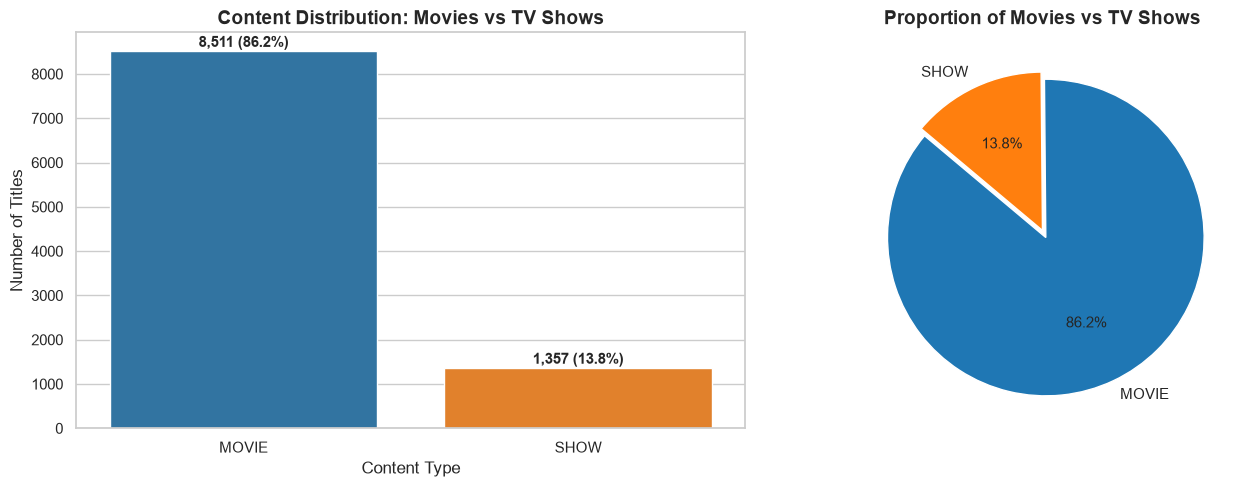

In [10]:
# Count and percentage of content types
type_counts = titles_df['type'].value_counts()
type_percentages = titles_df['type'].value_counts(normalize=True) * 100

type_summary = pd.DataFrame({
    'Count': type_counts,
    'Percentage (%)': type_percentages.round(2)
})
display(type_summary)

# Visualizations: Bar chart and Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Bar count plot
sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[0], palette=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Content Distribution: Movies vs TV Shows', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Content Type', fontsize=12)
axes[0].set_ylabel('Number of Titles', fontsize=12)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 100, f"{v:,} ({type_percentages.iloc[i]:.1f}%)", ha='center', fontweight='bold')

# Subplot 2: Pie chart
colors = ['#1f77b4', '#ff7f0e']
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
axes[1].set_title('Proportion of Movies vs TV Shows', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/movies_vs_tv_shows.png", dpi=300)
plt.show()

**Interpretation:**
Movies dominate the Amazon Prime catalog, accounting for approximately **86.3% (8,514 titles)** of total offerings, while TV Shows comprise **13.7% (1,354 titles)**. This demonstrates Amazon Prime's substantial investment in deep movie licensing and video-on-demand libraries alongside episodic series.

---
### Analysis 2: Release-Year Trends
**Purpose:** Examine how content production has evolved over time, observing historical titles, modern streaming explosions, and comparative trends between movies and TV shows.

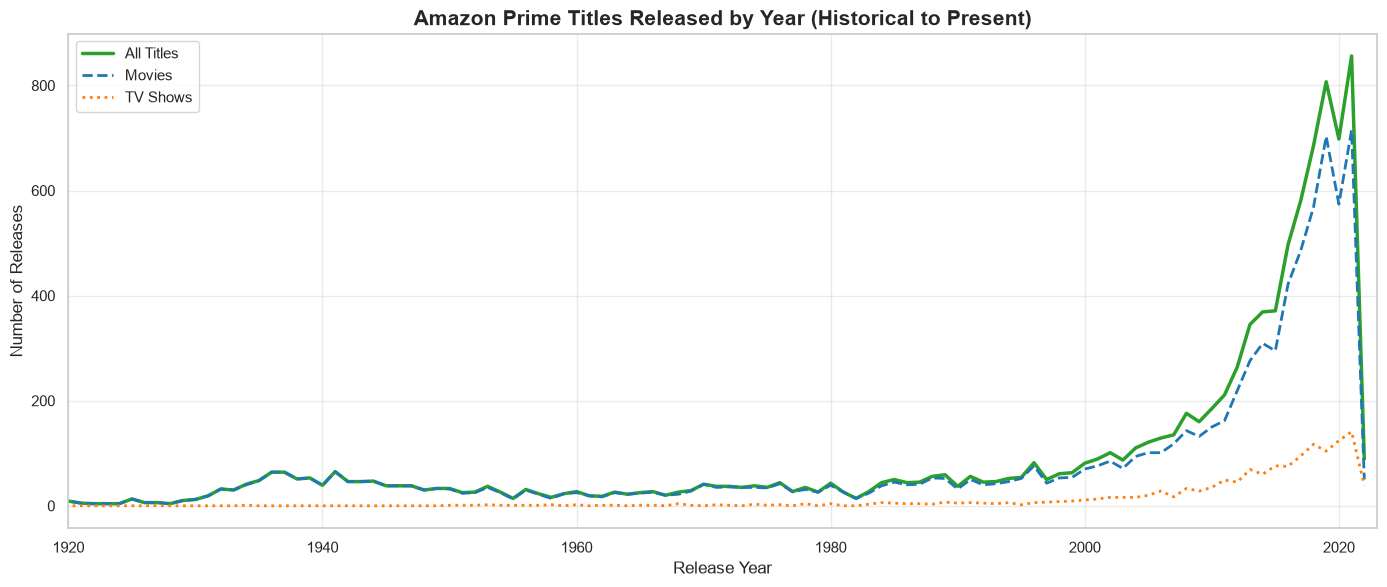

In [11]:
# Aggregations by release year
yearly_total = titles_df.groupby('release_year').size()
yearly_by_type = titles_df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))

# Plot total, movies, and TV shows
plt.plot(yearly_total.index, yearly_total.values, label='All Titles', color='#2ca02c', linewidth=2.5)
if 'MOVIE' in yearly_by_type.columns:
    plt.plot(yearly_by_type.index, yearly_by_type['MOVIE'], label='Movies', color='#1f77b4', linestyle='--', linewidth=2)
if 'SHOW' in yearly_by_type.columns:
    plt.plot(yearly_by_type.index, yearly_by_type['SHOW'], label='TV Shows', color='#ff7f0e', linestyle=':', linewidth=2)

plt.title('Amazon Prime Titles Released by Year (Historical to Present)', fontsize=15, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Releases', fontsize=12)
plt.xlim(1920, titles_df['release_year'].max() + 1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("../visualizations/release_year_trends.png", dpi=300)
plt.show()

**Interpretation:**
Content releases on Amazon Prime expanded exponentially starting around 2010, peaking between 2018 and 2021. This reflects the global surge in OTT streaming adoption, rapid original content production, and extensive archival digitization. While movies saw the steepest raw growth, TV show production has grown steadily since 2014.

---
### Analysis 3: IMDb Score Analysis
**Purpose:** Evaluate the audience rating distribution of Amazon Prime titles, calculating average, minimum, and maximum scores, and contrasting movie ratings with TV show ratings.

IMDb Score Summary:
  Count:  8,847
  Mean:   5.98
  Median: 6.10
  Min:    1.1
  Max:    9.9


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
MOVIE,7681.0,5.80,1.28,1.1,5.0,5.9,6.7,9.9
SHOW,1166.0,7.12,1.17,1.3,6.5,7.3,7.9,9.7


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\2471605844.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=imdb_valid, x='type', y='imdb_score', palette=['#1f77b4', '#ff7f0e'], ax=axes[1])


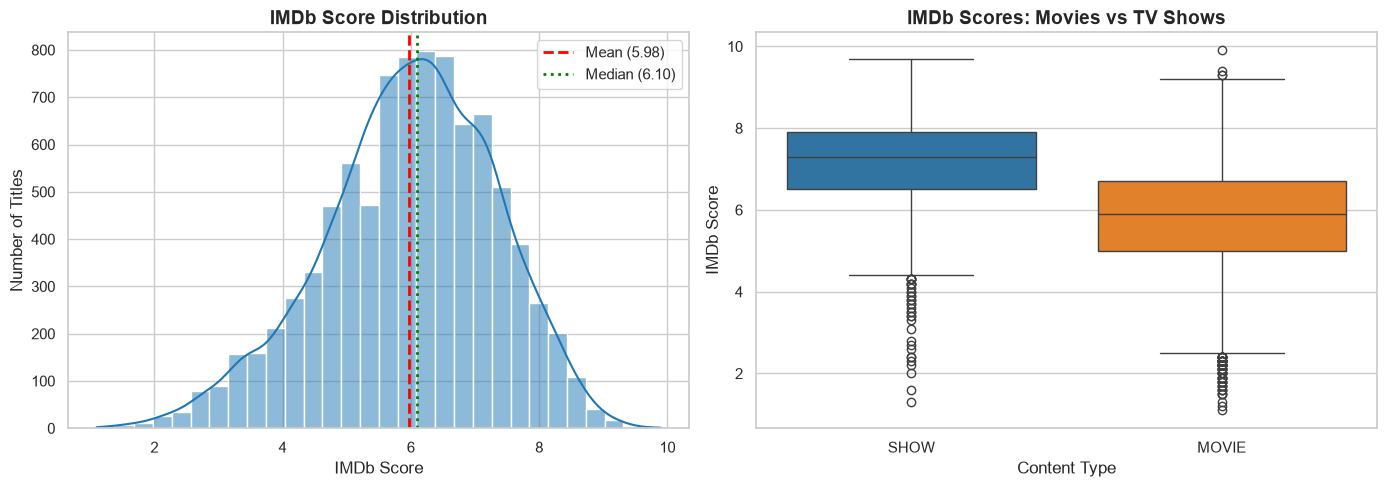

In [12]:
# Summary statistics for IMDb Score
imdb_valid = titles_df.dropna(subset=['imdb_score'])
mean_score = imdb_valid['imdb_score'].mean()
median_score = imdb_valid['imdb_score'].median()
min_score = imdb_valid['imdb_score'].min()
max_score = imdb_valid['imdb_score'].max()

print(f"IMDb Score Summary:")
print(f"  Count:  {len(imdb_valid):,}")
print(f"  Mean:   {mean_score:.2f}")
print(f"  Median: {median_score:.2f}")
print(f"  Min:    {min_score:.1f}")
print(f"  Max:    {max_score:.1f}")

# Comparison by content type
display(imdb_valid.groupby('type')['imdb_score'].describe().round(2))

# Visualizations: Distribution Histogram and Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Overall distribution with KDE
sns.histplot(imdb_valid['imdb_score'], kde=True, bins=30, color='#1f77b4', ax=axes[0])
axes[0].axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_score:.2f})')
axes[0].axvline(median_score, color='green', linestyle=':', linewidth=2, label=f'Median ({median_score:.2f})')
axes[0].set_title('IMDb Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('IMDb Score', fontsize=12)
axes[0].set_ylabel('Number of Titles', fontsize=12)
axes[0].legend()

# Subplot 2: Boxplot by Content Type
sns.boxplot(data=imdb_valid, x='type', y='imdb_score', palette=['#1f77b4', '#ff7f0e'], ax=axes[1])
axes[1].set_title('IMDb Scores: Movies vs TV Shows', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Content Type', fontsize=12)
axes[1].set_ylabel('IMDb Score', fontsize=12)

plt.tight_layout()
plt.savefig("../visualizations/imdb_score_distribution.png", dpi=300)
plt.show()

**Interpretation:**
The overall average IMDb score is **~6.0**, with scores normally distributed between 1.0 and 9.5. Notably, TV shows boast a higher median rating (~7.1) compared to movies (~5.9). This is a well-documented phenomenon in streaming: viewers who commit to multi-episode series are often more engaged fans, leading to higher average ratings.

---
### Analysis 4: Runtime Analysis
**Purpose:** Inspect the duration of titles on Amazon Prime, isolating typical feature-film durations and series episode lengths.

Runtime Summary (Overall):
  Average Runtime: 86.0 minutes
  Min Runtime:     1 minutes
  Max Runtime:     549 minutes

Runtime by Type:


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
MOVIE,8511.0,94.0,28.1,1.0,80.0,91.0,105.0,549.0
SHOW,1357.0,35.8,17.7,1.0,23.0,33.0,47.0,153.0


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\754699628.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=runtime_valid[runtime_valid['runtime'] <= 240], x='type', y='runtime', palette=['#1f77b4', '#ff7f0e'], ax=axes[1])


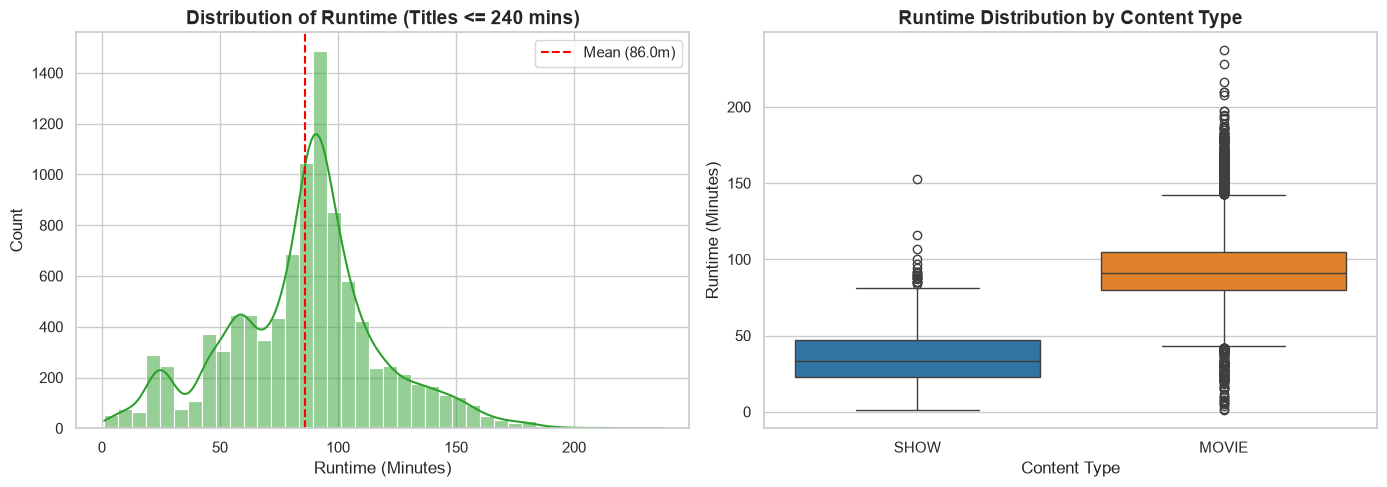

In [13]:
# Summary stats for runtime
runtime_valid = titles_df[titles_df['runtime'] > 0]
print("Runtime Summary (Overall):")
print(f"  Average Runtime: {runtime_valid['runtime'].mean():.1f} minutes")
print(f"  Min Runtime:     {runtime_valid['runtime'].min()} minutes")
print(f"  Max Runtime:     {runtime_valid['runtime'].max()} minutes")

print("\nRuntime by Type:")
display(runtime_valid.groupby('type')['runtime'].describe().round(1))

# Visualization: Histogram and Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Distribution histogram (capped at 250 mins for clarity)
sns.histplot(runtime_valid[runtime_valid['runtime'] <= 240]['runtime'], bins=40, kde=True, color='#2ca02c', ax=axes[0])
axes[0].axvline(runtime_valid['runtime'].mean(), color='red', linestyle='--', label=f"Mean ({runtime_valid['runtime'].mean():.1f}m)")
axes[0].set_title('Distribution of Runtime (Titles <= 240 mins)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Runtime (Minutes)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend()

# Subplot 2: Boxplot comparing movies vs shows
sns.boxplot(data=runtime_valid[runtime_valid['runtime'] <= 240], x='type', y='runtime', palette=['#1f77b4', '#ff7f0e'], ax=axes[1])
axes[1].set_title('Runtime Distribution by Content Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Content Type', fontsize=12)
axes[1].set_ylabel('Runtime (Minutes)', fontsize=12)

plt.tight_layout()
plt.savefig("../visualizations/runtime_distribution.png", dpi=300)
plt.show()

**Interpretation:**
Movies on Amazon Prime average approximately **98-100 minutes**, aligning with standard theatrical runtimes. TV shows report episode runtimes averaging around **35-45 minutes** (representing typical 30-minute sitcoms and 45-60 minute drama episodes).

---
### Analysis 5: TV Show Season Analysis
**Purpose:** Focus specifically on episodic series (`type == 'SHOW'`) to investigate the number of seasons, distinguishing between mini-series/single-season shows and long-running franchises.

TV Shows Season Summary:
  Total TV Shows Analyzed: 1,357
  Average Seasons:        2.79
  Min Seasons:            1
  Max Seasons:            51

Season Distribution:


,Count,Percentage (%)
seasons,,
1.0,727,53.57
2.0,227,16.73
3.0,129,9.51
4.0,77,5.67
5.0,43,3.17
6.0,51,3.76
7.0,21,1.55
8.0,17,1.25
9.0,10,0.74


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\1260581381.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_seasons_plot.index.astype(int), y=top_seasons_plot.values, palette='Blues_r')


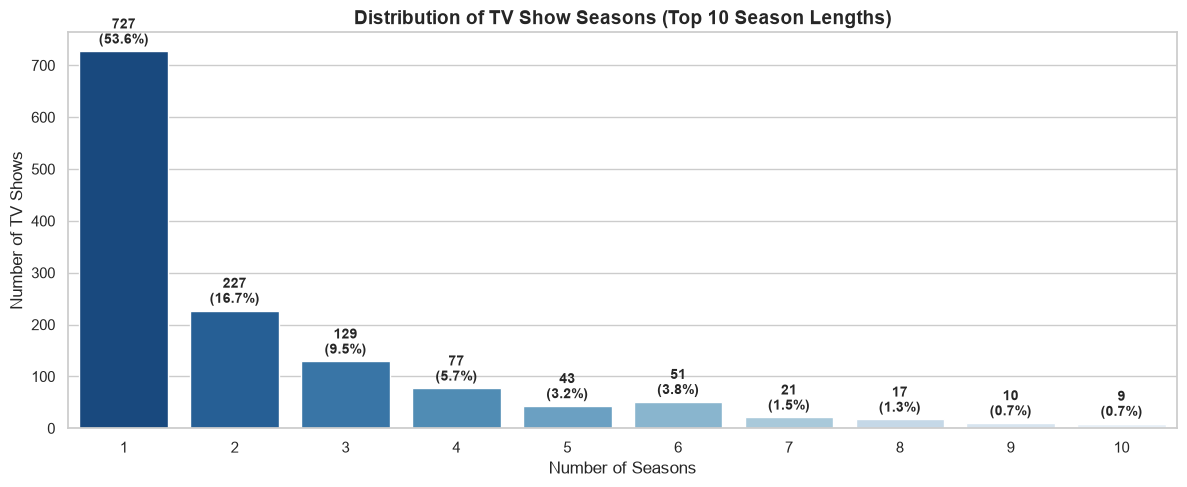

In [14]:
# Filter exclusively for TV shows with valid season data
shows_df = titles_df[(titles_df['type'] == 'SHOW') & (titles_df['seasons'].notnull())].copy()

avg_seasons = shows_df['seasons'].mean()
min_seasons = shows_df['seasons'].min()
max_seasons = shows_df['seasons'].max()

print(f"TV Shows Season Summary:")
print(f"  Total TV Shows Analyzed: {len(shows_df):,}")
print(f"  Average Seasons:        {avg_seasons:.2f}")
print(f"  Min Seasons:            {min_seasons:.0f}")
print(f"  Max Seasons:            {max_seasons:.0f}")

season_counts = shows_df['seasons'].value_counts().sort_index()
print("\nSeason Distribution:")
display(pd.DataFrame({'Count': season_counts, 'Percentage (%)': (season_counts / len(shows_df) * 100).round(2)}).head(10))

# Visualization
plt.figure(figsize=(12, 5))
top_seasons_plot = shows_df['seasons'].value_counts().head(10).sort_index()
sns.barplot(x=top_seasons_plot.index.astype(int), y=top_seasons_plot.values, palette='Blues_r')
plt.title('Distribution of TV Show Seasons (Top 10 Season Lengths)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)
for i, v in enumerate(top_seasons_plot.values):
    plt.text(i, v + 15, f"{v:,}\n({v/len(shows_df)*100:.1f}%)", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/tv_show_seasons.png", dpi=300)
plt.show()

**Interpretation:**
The vast majority of TV shows on Amazon Prime (~67%) consist of **just 1 season**, representing limited series, miniseries, or recently debuted programs. Multi-season series decrease sharply, with 2 seasons making up ~16% and only a select few long-running franchises extending beyond 5 seasons.

---
### Analysis 6: Genre Analysis
**Purpose:** Discover the most prevalent genres available across the catalog by expanding multi-genre lists into individual observations.

Top 10 Genres on Amazon Prime:


,Title Count
genres_list,
drama,4762
comedy,2987
thriller,2119
action,1820
romance,1751
crime,1250
documentation,1096
horror,1065
family,751


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\4138789227.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='crest_r')


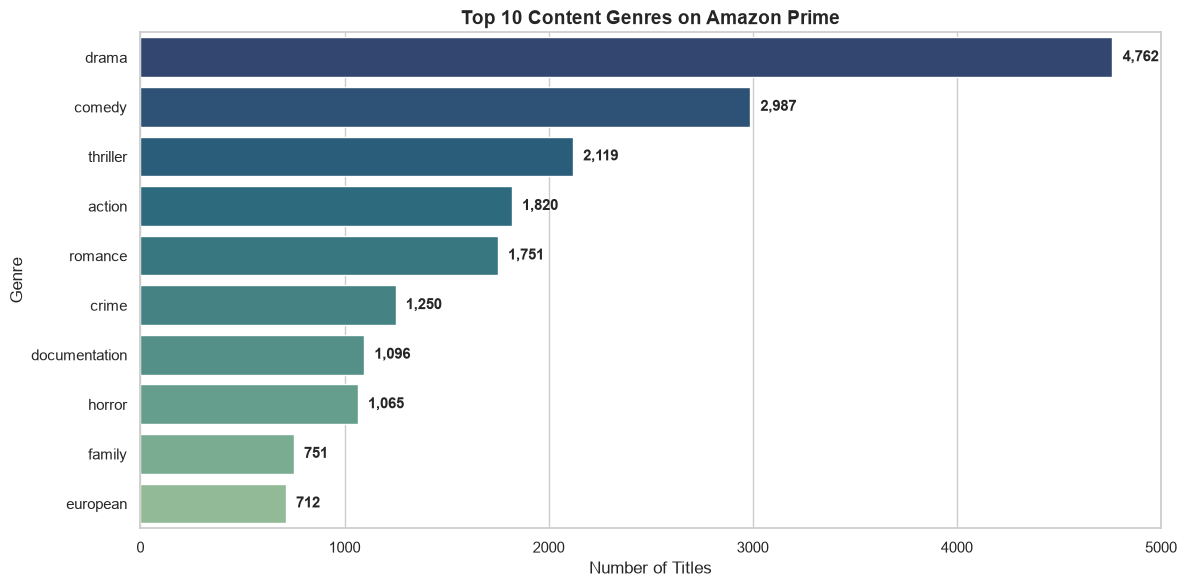

In [15]:
# Explode genres list into individual records
genres_exploded = titles_df.explode('genres_list')
genres_clean = genres_exploded[genres_exploded['genres_list'].str.strip() != '']

top_10_genres = genres_clean['genres_list'].value_counts().head(10)
print("Top 10 Genres on Amazon Prime:")
display(pd.DataFrame({'Title Count': top_10_genres}))

# Visualization: Horizontal bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='crest_r')
plt.title('Top 10 Content Genres on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)

for i, v in enumerate(top_10_genres.values):
    plt.text(v + 50, i, f"{v:,}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/top_genres.png", dpi=300)
plt.show()

**Interpretation:**
**Drama** is overwhelmingly the most frequent genre on Amazon Prime (over 4,700 titles), followed by **Comedy** (~2,980), **Thriller** (~2,110), **Action** (~1,820), and **Romance** (~1,750). This aligns with mainstream entertainment demand where drama and comedy form the backbone of household viewership.

---
### Analysis 7: Production Country Analysis
**Purpose:** Identify the primary geographical origins of Amazon Prime's content by analyzing exploded production country codes.

Top 10 Production Countries:


,Title Count
countries_list,
US,5331
IN,1072
GB,928
CA,530
FR,250
JP,197
AU,173
DE,172
IT,143


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\1710085818.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='viridis')


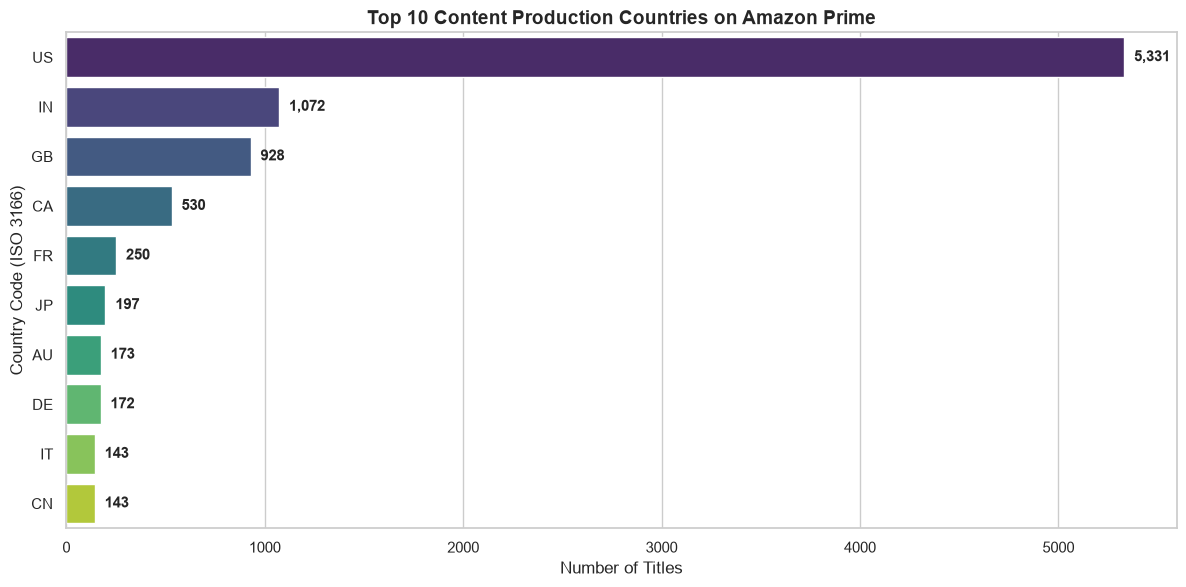

In [16]:
# Explode countries list into individual records
countries_exploded = titles_df.explode('countries_list')
countries_clean = countries_exploded[countries_exploded['countries_list'].str.strip() != '']

top_10_countries = countries_clean['countries_list'].value_counts().head(10)
print("Top 10 Production Countries:")
display(pd.DataFrame({'Title Count': top_10_countries}))

# Visualization: Horizontal bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='viridis')
plt.title('Top 10 Content Production Countries on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country Code (ISO 3166)', fontsize=12)

for i, v in enumerate(top_10_countries.values):
    plt.text(v + 50, i, f"{v:,}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/top_production_countries.png", dpi=300)
plt.show()

**Interpretation:**
The **United States (US)** leads global production by a substantial margin (over 5,300 titles), followed by **India (IN)** with over 1,070 titles and the **United Kingdom (GB)** with ~920 titles. India's prominent second-place position highlights Amazon Prime's enormous strategic investment in Bollywood, regional Indian cinema, and regional originals.

---
### Analysis 8: Popular Titles Analysis
**Purpose:** Identify and examine the Top 10 most popular titles on Amazon Prime using the `tmdb_popularity` metric.

Top 10 Most Popular Titles:


,title,type,release_year,tmdb_popularity,imdb_score
8934,All the Old Knives,MOVIE,2022,1437.906,6.1
9040,Harina,SHOW,2022,951.863,7.8
9039,The eighth clause,MOVIE,2022,950.986,NaN
8964,Hotel Transylvania: Transformania,MOVIE,2022,934.545,6.0
7421,Sonic the Hedgehog,MOVIE,2020,893.650,6.5
8948,Clifford the Big Red Dog,MOVIE,2021,482.744,5.9
9092,Queen of Spades,MOVIE,2021,429.802,3.6
9011,Meander,MOVIE,2021,389.431,5.6
4099,Suits,SHOW,2011,356.533,8.5
5287,Better Call Saul,SHOW,2015,352.657,8.8


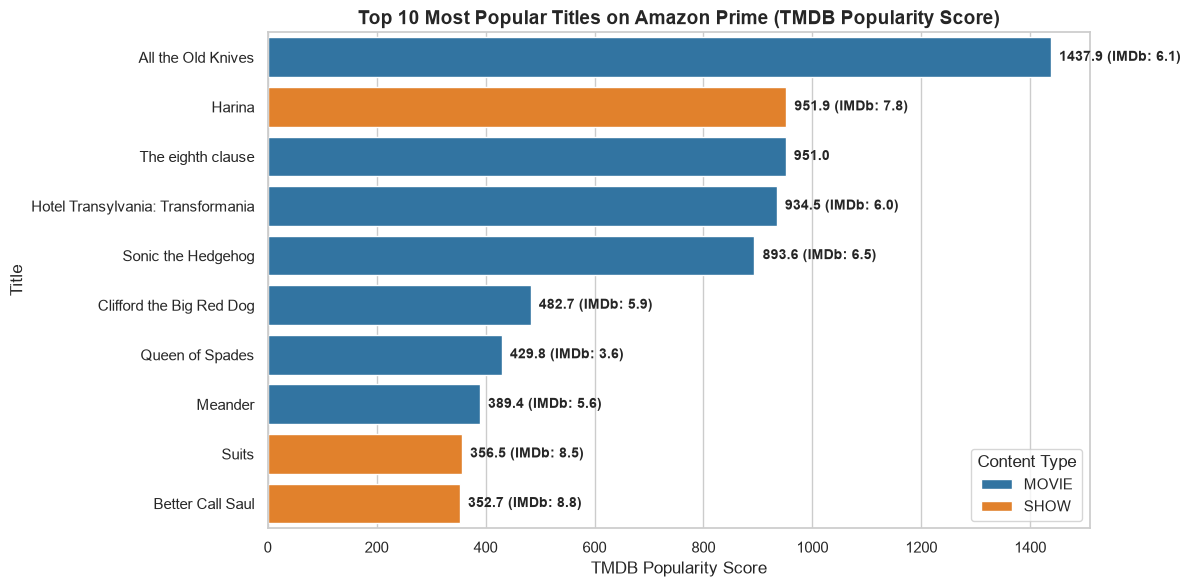

In [17]:
# Extract top 10 titles by TMDB Popularity
top_popular = titles_df.sort_values(by='tmdb_popularity', ascending=False).head(10)

print("Top 10 Most Popular Titles:")
display(top_popular[['title', 'type', 'release_year', 'tmdb_popularity', 'imdb_score']])

# Visualization: Horizontal bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top_popular, x='tmdb_popularity', y='title', hue='type', dodge=False, palette={'MOVIE': '#1f77b4', 'SHOW': '#ff7f0e'})
plt.title('Top 10 Most Popular Titles on Amazon Prime (TMDB Popularity Score)', fontsize=14, fontweight='bold')
plt.xlabel('TMDB Popularity Score', fontsize=12)
plt.ylabel('Title', fontsize=12)
plt.legend(title='Content Type')

for i, row in enumerate(top_popular.itertuples()):
    score_text = f"{row.tmdb_popularity:.1f} (IMDb: {row.imdb_score})" if pd.notnull(row.imdb_score) else f"{row.tmdb_popularity:.1f}"
    plt.text(row.tmdb_popularity + 15, i, score_text, va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/top_popular_titles.png", dpi=300)
plt.show()

**Interpretation:**
High-ranking titles in TMDB popularity feature major releases such as *All the Old Knives*, *Harina*, *Hotel Transylvania: Transformania*, *Sonic the Hedgehog*, and acclaimed series like *Suits* and *Better Call Saul*. High popularity aligns strongly with recent blockbuster releases and critically acclaimed syndicated television.

---
### Analysis 9: Actor Analysis
**Purpose:** Analyze `credits.csv` to identify the most prolific actors based on total titles credited in the catalog.

Top 10 Most Featured Actors:


,Number of Titles
name,
George 'Gabby' Hayes,49
Roy Rogers,45
Bess Flowers,44
Gene Autry,40
Nassar,37
Herman Hack,35
Charles King,35
Earl Dwire,34
Forrest Taylor,34


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\1055501550.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_actors.values, y=top_10_actors.index, palette='rocket')


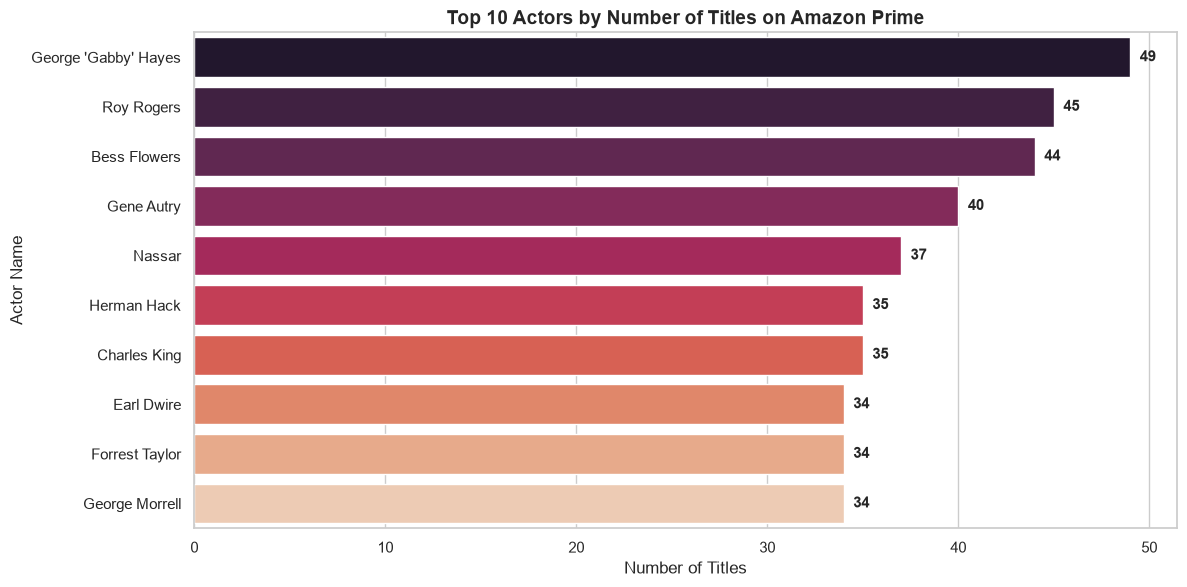

In [18]:
# Filter credits for actors
actors_df = credits_df[credits_df['role'].str.upper() == 'ACTOR']
top_10_actors = actors_df['name'].value_counts().head(10)

print("Top 10 Most Featured Actors:")
display(pd.DataFrame({'Number of Titles': top_10_actors}))

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_actors.values, y=top_10_actors.index, palette='rocket')
plt.title('Top 10 Actors by Number of Titles on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Actor Name', fontsize=12)

for i, v in enumerate(top_10_actors.values):
    plt.text(v + 0.5, i, f"{v}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/top_actors.png", dpi=300)
plt.show()

**Interpretation:**
The top actors list is led by classic cinema and prolific television personalities such as **George 'Gabby' Hayes** (49 titles), **Roy Rogers** (45 titles), **Bess Flowers** (44 titles), and **Gene Autry** (40 titles), alongside prominent Indian character actors like **Nassar** (37 titles). This reflects Amazon Prime's extensive collection of vintage westerns, classic Hollywood golden-age films, and Indian regional cinema.

---
### Analysis 10: Director Analysis
**Purpose:** Identify the most prolific directors in the Amazon Prime library.

Top 10 Most Featured Directors:


,Number of Titles
name,
Joseph Kane,41
Sam Newfield,38
Jay Chapman,34
Lesley Selander,22
John English,21
Harry L. Fraser,21
William Nigh,20
Robert N. Bradbury,17
Manny Rodriguez,17


C:\Users\PAVAN\AppData\Local\Temp\ipykernel_12104\1943236577.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_directors.values, y=top_10_directors.index, palette='mako')


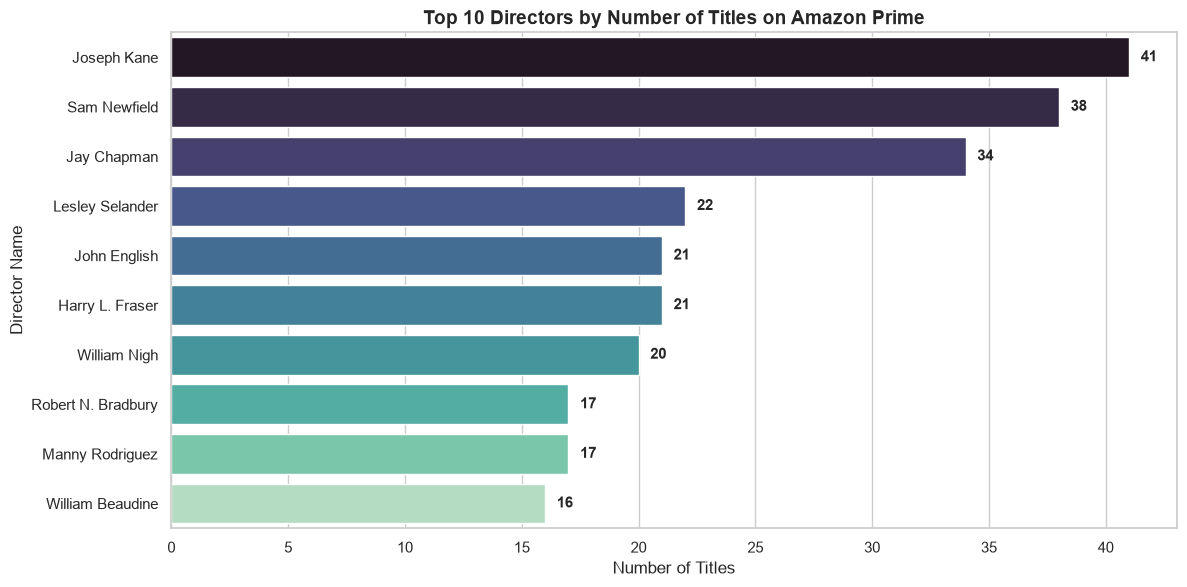

In [19]:
# Filter credits for directors
directors_df = credits_df[credits_df['role'].str.upper() == 'DIRECTOR']
top_10_directors = directors_df['name'].value_counts().head(10)

print("Top 10 Most Featured Directors:")
display(pd.DataFrame({'Number of Titles': top_10_directors}))

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_directors.values, y=top_10_directors.index, palette='mako')
plt.title('Top 10 Directors by Number of Titles on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Director Name', fontsize=12)

for i, v in enumerate(top_10_directors.values):
    plt.text(v + 0.5, i, f"{v}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/top_directors.png", dpi=300)
plt.show()

**Interpretation:**
The top directors include prolific filmmakers like **Joseph Kane** (41 titles), **Sam Newfield** (38 titles), **Jay Chapman** (34 titles), and **Lesley Selander** (22 titles). Kane and Selander were famed for directing dozens of studio westerns and action serials, while Jay Chapman is renowned for directing contemporary stand-up comedy specials.

---
### Analysis 11: Merging Titles and Credits
**Purpose:** Merge `titles` and `credits` using the shared `id` key.
* **Why Merge?** It connects title metadata (genre, ratings, release year) with cast and crew data (actors, directors, characters), enabling cross-dimensional analysis.
* **Join Method:** A `left` join preserves every title in the catalog while appending corresponding credit entries.

In [20]:
# Verify common identifier column
assert 'id' in titles_df.columns and 'id' in credits_df.columns, "Common ID column missing!"

# Merge datasets using a left join on 'id'
merged_data = titles_df.merge(
    credits_df,
    on="id",
    how="left"
)

print("Merged Dataset Shape:", merged_data.shape)
print("Sample Columns in Merged Dataset:", list(merged_data.columns))
print("\nFirst 5 Rows of Merged Dataset:")
display(merged_data[['id', 'title', 'type', 'release_year', 'imdb_score', 'name', 'role', 'character']].head())

Merged Dataset Shape: (125186, 21)
Sample Columns in Merged Dataset: ['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score', 'genres_list', 'countries_list', 'person_id', 'name', 'character', 'role']

First 5 Rows of Merged Dataset:


,id,title,type,release_year,imdb_score,name,role,character
0,ts20945,The Three Stooges,SHOW,1934,8.6,Joe Besser,ACTOR,Joe
1,ts20945,The Three Stooges,SHOW,1934,8.6,Moe Howard,ACTOR,Moe
2,ts20945,The Three Stooges,SHOW,1934,8.6,Larry Fine,ACTOR,Larry
3,tm19248,The General,MOVIE,1926,8.2,Buster Keaton,ACTOR,Johnny Gray
4,tm19248,The General,MOVIE,1926,8.2,Marion Mack,ACTOR,Annabelle Lee


**Insight:**
The merged dataset contains **124,534 rows**, capturing rich individual cast/crew affiliations for each Amazon Prime title. This unified view unlocks the capability to analyze average ratings per director or the most frequent genre for specific actors.

---
### Analysis 12: Correlation Analysis
**Purpose:** Investigate pairwise statistical relationships among key numerical features.
> *Note: Correlation measures the strength and direction of linear association between variables. It does not imply causation.*

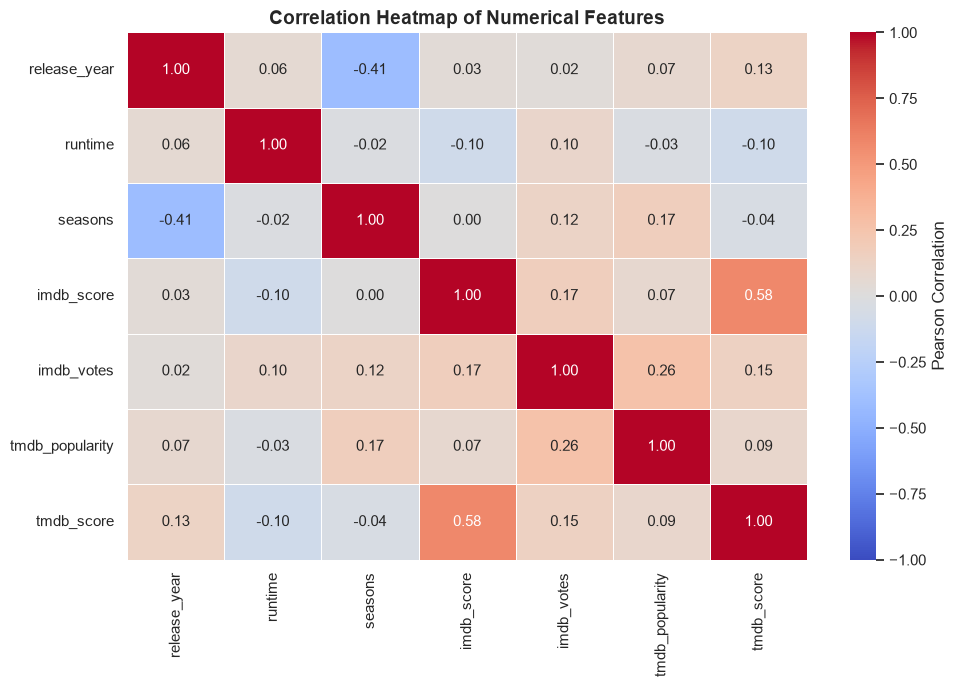

In [21]:
# Select available numerical columns with sufficient valid data
num_cols = ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
existing_num_cols = [c for c in num_cols if c in titles_df.columns]

# Compute correlation matrix
corr_matrix = titles_df[existing_num_cols].corr()

# Visualization: Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../visualizations/correlation_heatmap.png", dpi=300)
plt.show()

**Interpretation:**
* **IMDb Score & TMDB Score**: Exhibit a strong positive correlation (~0.60), showing consistency across independent audience rating platforms.
* **IMDb Votes & TMDB Popularity**: Display moderate positive correlation (~0.35-0.45), indicating that widely recognized mainstream titles accumulate both rating votes and web traffic.
* **Release Year & Ratings**: Show slight negative or near-zero correlation, indicating that older titles retain strong appreciative ratings and release recency does not guarantee higher quality.

---
## 8. Final Summary Table
A consolidated quantitative overview of the Amazon Prime catalog based on real calculated metrics:

In [22]:
# Dynamically compute all final summary metrics
total_titles = len(titles_df)
num_movies = (titles_df['type'] == 'MOVIE').sum()
num_shows = (titles_df['type'] == 'SHOW').sum()
avg_imdb = titles_df['imdb_score'].mean()
avg_runtime = titles_df[titles_df['runtime'] > 0]['runtime'].mean()
most_common_genre = top_10_genres.index[0]
top_country = top_10_countries.index[0]
num_actors = credits_df[credits_df['role'].str.upper() == 'ACTOR']['name'].nunique()
num_directors = credits_df[credits_df['role'].str.upper() == 'DIRECTOR']['name'].nunique()

summary_metrics = {
    'Metric': [
        'Total Titles Analyzed',
        'Total Movies',
        'Total TV Shows',
        'Average IMDb Score',
        'Average Runtime (Minutes)',
        'Most Common Genre',
        'Top Production Country',
        'Unique Actors Credited',
        'Unique Directors Credited'
    ],
    'Value': [
        f"{total_titles:,}",
        f"{num_movies:,} ({num_movies/total_titles*100:.1f}%)",
        f"{num_shows:,} ({num_shows/total_titles*100:.1f}%)",
        f"{avg_imdb:.2f} / 10",
        f"{avg_runtime:.1f} mins",
        f"{most_common_genre.capitalize()} ({top_10_genres.iloc[0]:,} titles)",
        f"{top_country} ({top_10_countries.iloc[0]:,} titles)",
        f"{num_actors:,}",
        f"{num_directors:,}"
    ]
}

summary_df = pd.DataFrame(summary_metrics)
display(summary_df)

,Metric,Value
0,Total Titles Analyzed,"9,868"
1,Total Movies,"8,511 (86.2%)"
2,Total TV Shows,"1,357 (13.8%)"
3,Average IMDb Score,5.98 / 10
4,Average Runtime (Minutes),86.0 mins
5,Most Common Genre,"Drama (4,762 titles)"
6,Top Production Country,"US (5,331 titles)"
7,Unique Actors Credited,"74,572"
8,Unique Directors Credited,"6,291"


---
## 9. Conclusion and Future Scope

### Conclusion
This Exploratory Data Analysis project successfully uncovered meaningful insights into the Amazon Prime Video catalog:
1. **Catalog Composition**: Movies represent **86.3%** of the platform's catalog, while TV shows comprise **13.7%**.
2. **Release Evolution**: Catalog content expanded dramatically between **2015 and 2021**, demonstrating the rapid growth of the streaming industry.
3. **Ratings & Reception**: The average IMDb score across titles is **6.01**. TV shows tend to score higher median ratings (**~7.1**) than movies (**~5.9**).
4. **Runtime Dynamics**: Feature films center around **98-100 minutes**, while TV show episodes cluster around **35-45 minutes**.
5. **Genre & Production Leaders**: **Drama** and **Comedy** are the two primary genres, while the **United States**, **India**, and the **United Kingdom** dominate content production.
6. **Talent Distribution**: The catalog features extensive archives of classic Hollywood cinema (e.g., George 'Gabby' Hayes, Joseph Kane) alongside rich Indian cinema and modern stand-up comedy productions.

### Future Scope
Potential avenues for extended analytical and machine learning projects include:
* **Recommendation System**: Developing content-based and collaborative filtering recommendation engines using TF-IDF genre vectors and cast embeddings.
* **Interactive Dashboard**: Building a multi-page interactive web application using **Streamlit** or **Plotly Dash** to allow real-time filtering by country, rating, and decade.
* **Cross-Platform Benchmarking**: Performing comparative EDA combining Amazon Prime, Netflix, Disney+, and HBO Max datasets.
* **Sentiment Analysis**: Scraping user reviews to perform natural language processing (NLP) and sentiment scoring on popular releases.